# Do Subpopulation Models Help?

1) Split people into groups and fit a model in each one.

2) Reweight. Do not split at all. Fit on everybody, but change the sample weights so the model pays more
attention to some people than others, and combine several such models into an ensemble.

## Part 0. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.cluster import KMeans
from sklearn.metrics import log_loss
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from sklearn.tree import DecisionTreeRegressor, export_text
from scipy.optimize import minimize
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
SEED = 42

In [2]:
df = pd.read_csv("clean-compas-scores-two-year.csv")
df["sex_male"] = (df["sex"] == "Male").astype(int)
df["charge_felony"] = (df["c_charge_degree"] == "F").astype(int)
df["race_age"] = df["race_for_model"] + " / " + df["age_cat"]

# the nine features every model in this notebook uses
FEATURES = ["age", "priors_count", "juv_fel_count", "juv_misd_count", "juv_other_count",
            "len_of_stay", "days_b_screening_arrest", "sex_male", "charge_felony"]
X = df[FEATURES]
# standardised copy for the linear models
Xs = StandardScaler().fit_transform(X)
y_real = df["two_year_recid"].values
J = FEATURES.index("priors_count")

print(f"{len(df)} people, {len(FEATURES)} features, recidivism rate {y_real.mean():.3f}")

6172 people, 9 features, recidivism rate 0.455


The three synthetic datasets, same as the other notebooks, real features and made up labels. In A
everyone follows one rule, so there is nothing to find and the true answer is nothing. In B priors
works backwards for the under 25s, so the flip sits inside a demographic group. In C priors works
backwards for the longest staying 20 percent, so the flip cuts across demographics. B and C are
deliberately the same size, so the only difference between them is where the flip lives rather than
how big it is.

In [3]:
def make_xgb():
    return XGBClassifier(n_estimators=200, max_depth=3, learning_rate=0.05, subsample=0.8,
                         colsample_bytree=0.8, reg_lambda=1.0, eval_metric="logloss",
                         random_state=SEED, verbosity=0)

# out of fold xgb probabilities on the real data become the generating rule
p_gen = np.clip(cross_val_predict(make_xgb(), X.values, y_real, cv=5, method="predict_proba")[:, 1],
                1e-6, 1 - 1e-6)
LOGIT = np.log(p_gen / (1 - p_gen))
# the real fitted priors coefficient, reused as the size of the planted flip
BETA_P = LogisticRegression(max_iter=3000).fit(Xs, y_real).coef_[0][J]

GROUP_B = (df["age_cat"] == "Less than 25").values
GROUP_C = (df["len_of_stay"] >= df["len_of_stay"].quantile(0.80)).values

def make_synthetic(which, rng):
    rule = LOGIT.copy()
    # flip the priors effect for the chosen group, A keeps the rule untouched
    if which == "B":
        rule = rule - 2 * BETA_P * Xs[:, J] * GROUP_B
    if which == "C":
        rule = rule - 2 * BETA_P * Xs[:, J] * GROUP_C
    # draw labels from the rule so only the labels differ between datasets
    return rng.binomial(1, 1 / (1 + np.exp(-rule)))

print(f"group B, the under 25s, is {GROUP_B.mean():.0%} of people")
print(f"group C, the longest stays, is {GROUP_C.mean():.0%} of people")


group B, the under 25s, is 22% of people
group C, the longest stays, is 21% of people


Fine grained subgroups, race by sex by age bucket by priors bucket. These are the atoms that
everything in Part 2 will either select from or merge together.

In [4]:
# bucket age and priors, then paste race, sex and the buckets into one label
age_b = pd.cut(df["age"], [17, 25, 35, 45, 100], labels=["18-25", "26-35", "36-45", "46+"])
pri_b = pd.cut(df["priors_count"], [-0.1, 0, 2, 5, 100], labels=["0", "1-2", "3-5", "6+"])
gran = (df["race_for_model"].str[:5] + "|" + df["sex"].str[0] + "|"
        + age_b.astype(str) + "|" + pri_b.astype(str))

# atoms need at least 60 people to be scoreable
SUBGROUPS = [g for g in gran.unique() if (gran == g).sum() >= 60]
print(f"{gran.nunique()} subgroups, {len(SUBGROUPS)} with at least 60 people")
print(f"those cover {gran.isin(SUBGROUPS).mean():.0%} of the data")


94 subgroups, 39 with at least 60 people
those cover 79% of the data


The scoring harness for any partition. cv_gain compares one global model against one model per
cluster, cross validated, and positive means the clusters help. People in cluster minus one have no
cluster and keep the global model, and the same happens to anyone whose cluster is too small to fit
a model in.

In [5]:
def cv_gain(y, partition, min_n=80, seed=SEED):
    # out of fold predictions from one global model and from one model per cluster
    partition = pd.Series(np.asarray(partition))
    p_global = np.zeros(len(y))
    p_local = np.zeros(len(y))

    for tr, te in StratifiedKFold(5, shuffle=True, random_state=seed).split(Xs, y):
        sc = StandardScaler().fit(Xs[tr])
        A, B = sc.transform(Xs[tr]), sc.transform(Xs[te])

        # global model for this fold, everyone starts with its predictions
        gm = LogisticRegression(max_iter=3000).fit(A, y[tr])
        p_global[te] = gm.predict_proba(B)[:, 1]
        p_local[te] = p_global[te]

        # overwrite with a cluster model where the cluster is big enough to fit one
        for c in partition.iloc[tr].unique():
            if c == -1:
                continue
            trm = (partition.iloc[tr] == c).values
            tem = (partition.iloc[te] == c).values
            if trm.sum() < min_n or len(np.unique(y[tr][trm])) < 2 or tem.sum() == 0:
                continue
            lm = LogisticRegression(max_iter=3000).fit(A[trm], y[tr][trm])
            p_local[np.array(te)[tem]] = lm.predict_proba(B[tem])[:, 1]

    # positive means the cluster models helped
    return log_loss(y, p_global) - log_loss(y, p_local)


## Part 1. What a flip looks like

From EDA


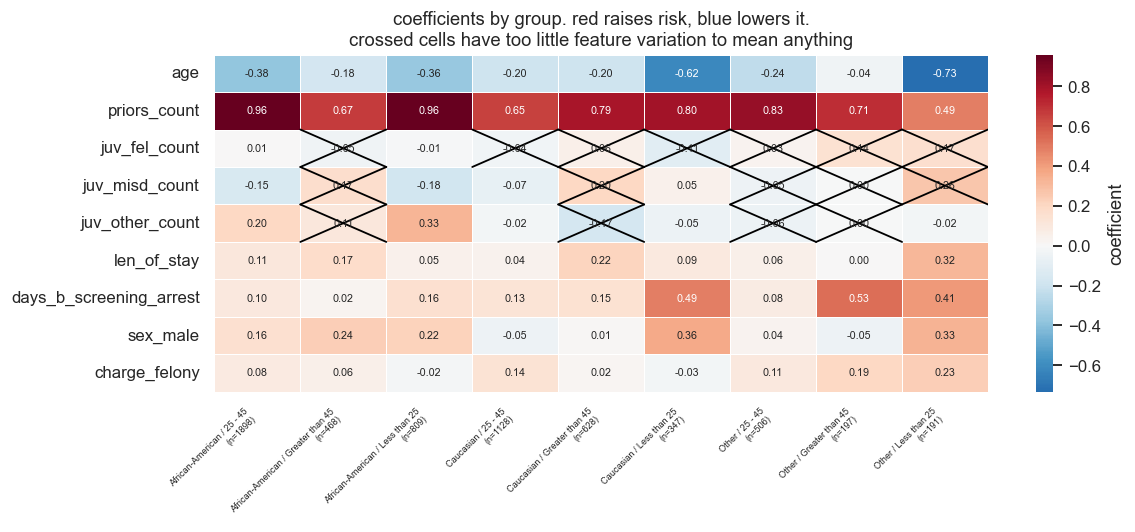

16 of 81 cells cannot be interpreted. all of them are juvenile counts,
which are zero for almost everybody.


In [6]:
groups_ra = df["race_age"]
coefs = {}
support = {}

# one logistic regression per race by age group, keep its coefficients
for g in sorted(groups_ra.unique()):
    m = (groups_ra == g).values
    if m.sum() < 100 or len(np.unique(y_real[m])) < 2:
        continue
    fit = LogisticRegression(C=1.0, max_iter=3000).fit(
        StandardScaler().fit_transform(X[m]), y_real[m])
    key = f"{g}\n(n={m.sum()})"
    coefs[key] = pd.Series(fit.coef_[0], index=FEATURES)
    support[key] = pd.Series((X.values[m] != 0).sum(axis=0), index=FEATURES)

C = pd.DataFrame(coefs)
S = pd.DataFrame(support)

fig, ax = plt.subplots(figsize=(11, 5))
sns.heatmap(C, annot=True, fmt=".2f", center=0, cmap="RdBu_r", linewidths=.5,
            annot_kws={"size": 7}, cbar_kws={"label": "coefficient"}, ax=ax)

# cross out cells where fewer than 20 people have a nonzero value of the feature
for i, f in enumerate(C.index):
    for j, g in enumerate(C.columns):
        if S.loc[f, g] < 20:
            ax.plot([j, j + 1], [i, i + 1], color="black", lw=1.2)
            ax.plot([j, j + 1], [i + 1, i], color="black", lw=1.2)

ax.set_title("coefficients by group. red raises risk, blue lowers it.\n"
             "crossed cells have too little feature variation to mean anything")
ax.set_xticklabels(ax.get_xticklabels(), fontsize=6, rotation=45, ha="right")
plt.tight_layout()
plt.show()

crossed = sum(1 for f in C.index for g in C.columns if S.loc[f, g] < 20)
print(f"{crossed} of {C.size} cells cannot be interpreted. all of them are juvenile counts,")
print("which are zero for almost everybody.")


## Part 2. Finding a partition

1) Loss landscape. Find the subgroups where the global model does worst, and give those their own model.

2) Coefficient merge. Fit a model inside every fine grained subgroup, then merge the subgroups whose
coefficients look alike.

3) Prediction profile K means. Group people by how a zoo of models predicts them.

### Method 1. The loss landscape

Measure the global model's out of fold loss inside every fine grained subgroup, and the worst ones
are the hard clusters. They get picked once from the real data. The features are identical in all
four datasets, so the same clusters can be reused everywhere, which holds the cluster sizes and
geometry fixed and leaves the labels as the only thing that changes. Min #people per group is 60

In [7]:
# out of fold predictions from the global model
p_glob = cross_val_predict(
    make_pipeline(StandardScaler(), LogisticRegression(max_iter=3000)),
    Xs, y_real, cv=5, method="predict_proba")[:, 1]

# loss inside every subgroup with at least 60 people
rows = []
for g in gran.unique():
    m = (gran == g).values
    if m.sum() < 60 or len(np.unique(y_real[m])) < 2:
        continue
    rows.append({"cluster": g, "n": int(m.sum()),
                 "global_loss": log_loss(y_real[m], p_glob[m], labels=[0, 1])})
land = pd.DataFrame(rows).sort_values("global_loss", ascending=False)

print("where the global model struggles most")
print(land.head(8).round(3).to_string(index=False))

# the five worst subgroups are the hard clusters
HARD = list(land.head(5)["cluster"])
HARD_MASK = gran.isin(HARD).values
print()
print(f"the five hard clusters hold {HARD_MASK.sum()} people, {HARD_MASK.mean():.0%} of the data")


where the global model struggles most
          cluster   n  global_loss
Afric|M|36-45|3-5  62        0.704
Cauca|M|36-45|3-5  63        0.702
  Cauca|M|18-25|0 144        0.689
   Afric|M|46+|6+ 152        0.688
  Afric|M|46+|3-5  82        0.687
Cauca|M|26-35|3-5  98        0.681
 Afric|M|36-45|6+ 166        0.678
Other|M|18-25|1-2  61        0.676

the five hard clusters hold 503 people, 8% of the data


Before merging or reweighting anything, how the loss is distributed over people, what does the mean loss do as the
hardest people are removed?

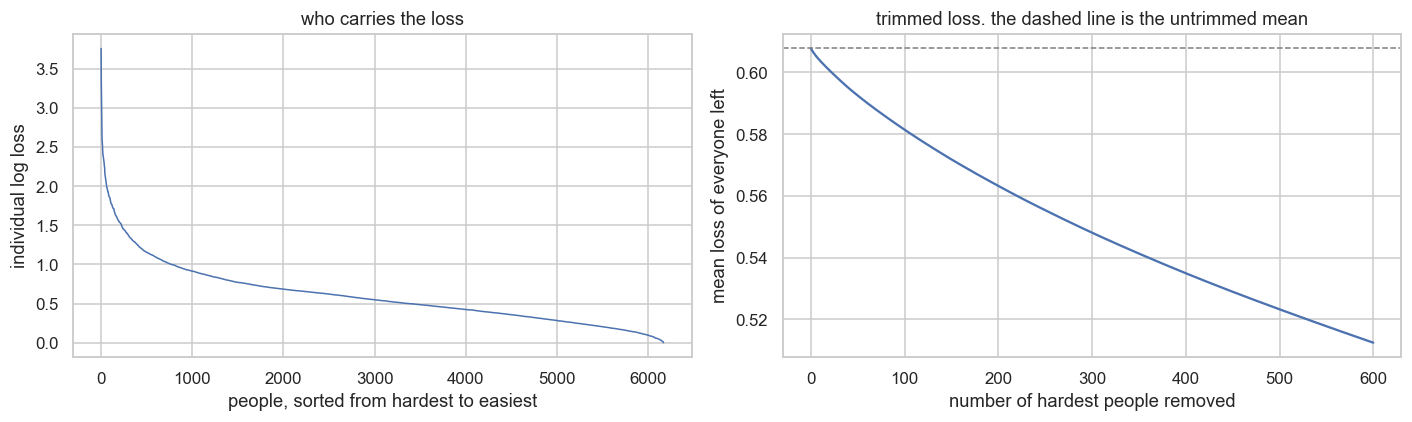

mean loss over everyone                0.6078
mean of the  20 hardest people         2.8012
mean of the 100 hardest people         2.2066
mean of the 200 hardest people         1.9377
mean of the 500 hardest people         1.5668
mean after removing the 200 hardest    0.5632


In [8]:
# each person's own out of fold loss
pp_loss = -(y_real * np.log(np.clip(p_glob, 1e-12, 1)) +
            (1 - y_real) * np.log(np.clip(1 - p_glob, 1e-12, 1)))
order = np.argsort(pp_loss)[::-1]
sorted_loss = pp_loss[order]

# mean loss after removing the k hardest people, for k up to 600
ks = np.arange(0, 601)
trimmed = [sorted_loss[k:].mean() for k in ks]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(sorted_loss, lw=1)
axes[0].set_xlabel("people, sorted from hardest to easiest")
axes[0].set_ylabel("individual log loss")
axes[0].set_title("who carries the loss")
axes[1].plot(ks, trimmed, lw=1.5)
axes[1].axhline(pp_loss.mean(), ls="--", c="gray", lw=1)
axes[1].set_xlabel("number of hardest people removed")
axes[1].set_ylabel("mean loss of everyone left")
axes[1].set_title("trimmed loss. the dashed line is the untrimmed mean")
plt.tight_layout()
plt.show()

print(f"mean loss over everyone                {pp_loss.mean():.4f}")
for k in [20, 100, 200, 500]:
    print(f"mean of the {k:3d} hardest people         {sorted_loss[:k].mean():.4f}")
print(f"mean after removing the 200 hardest    {sorted_loss[200:].mean():.4f}")


The loss lives in a tail. A couple of hundred people out of 6172 carry a disproportionate share of
it, and the hardest few dozen average several times the overall mean. The open question is whether
that tail is structure or noise.

In [9]:
def worst_slice(y, p):
    pp = -(y * np.log(np.clip(p, 1e-12, 1)) + (1 - y) * np.log(np.clip(1 - p, 1e-12, 1)))
    # a shallow tree fitted to per person loss, its leaves are candidate slices
    tree = DecisionTreeRegressor(max_depth=3, min_samples_leaf=50, random_state=SEED).fit(X, pp)
    stats = (pd.DataFrame({"leaf": tree.apply(X), "loss": pp})
             .groupby("leaf")["loss"].agg(["mean", "size"]))
    # the worst leaf's mean loss relative to the overall mean
    return stats["mean"].max() / pp.mean(), stats, tree

ratio_real, stats_real, tree_real = worst_slice(y_real, p_glob)
print("the tree's description of where the global model fails on real COMPAS")
print(export_text(tree_real, feature_names=FEATURES, max_depth=2))
print("leaves sorted by mean loss, size is how many people the rule covers")
print(stats_real.sort_values("mean", ascending=False).round(3).head(6).to_string())

# the same search on three draws of synthetic A gives the ratio a null
ratios_A = []
for r in range(3):
    yA = make_synthetic("A", np.random.default_rng(2000 + r))
    pA = cross_val_predict(make_pipeline(StandardScaler(), LogisticRegression(max_iter=3000)),
                           Xs, yA, cv=5, method="predict_proba")[:, 1]
    ratios_A.append(worst_slice(yA, pA)[0])

print()
print(f"worst slice loss over mean loss, real COMPAS   {ratio_real:.2f}")
print(f"same search on synthetic A                     {np.mean(ratios_A):.2f} "
      f"plus or minus {np.std(ratios_A):.2f}")


the tree's description of where the global model fails on real COMPAS
|--- priors_count <= 15.50
|   |--- age <= 52.50
|   |   |--- priors_count <= 7.50
|   |   |   |--- value: [0.63]
|   |   |--- priors_count >  7.50
|   |   |   |--- value: [0.57]
|   |--- age >  52.50
|   |   |--- priors_count <= 0.50
|   |   |   |--- value: [0.35]
|   |   |--- priors_count >  0.50
|   |   |   |--- value: [0.63]
|--- priors_count >  15.50
|   |--- age <= 39.50
|   |   |--- age <= 33.50
|   |   |   |--- value: [0.22]
|   |   |--- age >  33.50
|   |   |   |--- value: [0.44]
|   |--- age >  39.50
|   |   |--- value: [0.67]

leaves sorted by mean loss, size is how many people the rule covers
       mean  size
leaf             
12    0.669    96
7     0.634   352
3     0.629  4813
4     0.567   566
11    0.442    51
6     0.347   229

worst slice loss over mean loss, real COMPAS   1.10
same search on synthetic A                     1.24 plus or minus 0.12


### Method 2. Coefficient merge

Fit a logistic regression inside each fine grained subgroup and treat its nine coefficients as that
subgroup's profile, then merge subgroups whose profiles look alike. The regularisation is a little
tighter than usual, C of 0.5 rather than 1.0, because these are small groups and loose coefficients
are noisy, and people in subgroups too small to profile get minus one, which means they keep the
global model.

This is the key difference from prediction profile clustering. That one groups people by their
predicted risk, and predicted risk is built out of all the features, so conditioning on it induces
relationships between the features that are not really there. This one groups subgroups by their
fitted coefficients, which is not a function of any individual's prediction, so there is no
collider.

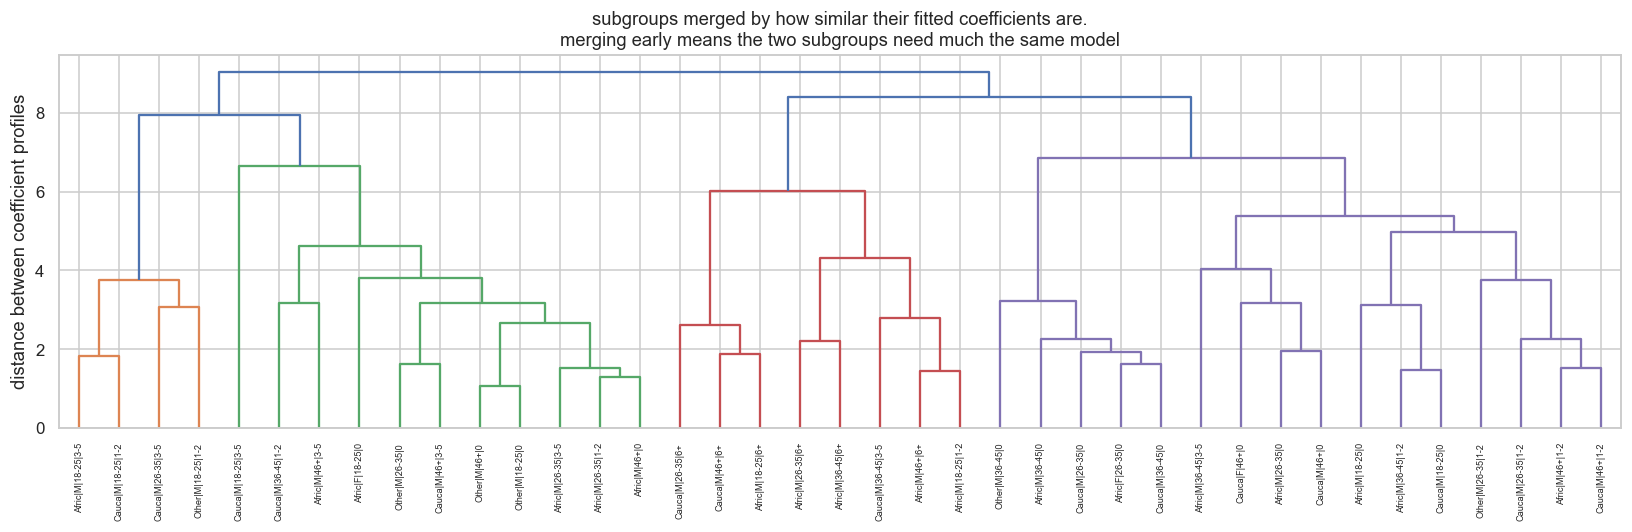

In [10]:
def coefficient_profiles(y):
    # one small logistic regression per subgroup, its coefficients are the profile
    prof = {}
    for g in SUBGROUPS:
        m = (gran == g).values
        if len(np.unique(y[m])) < 2:
            continue
        prof[g] = LogisticRegression(C=0.5, max_iter=3000).fit(
            StandardScaler().fit_transform(X[m]), y[m]).coef_[0]
    return pd.DataFrame(prof, index=FEATURES).T

def coef_merge_partition(y, K):
    # ward merge on the profiles, then map every person to their subgroup's cluster
    P = coefficient_profiles(y)
    Z = linkage(StandardScaler().fit_transform(P.values), method="ward")
    labels = fcluster(Z, t=K, criterion="maxclust")
    sub_to_cluster = dict(zip(P.index, labels))
    return gran.map(sub_to_cluster).fillna(-1).astype(int).values

# the dendrogram of the real data's profiles
P_real = coefficient_profiles(y_real)
Z_real = linkage(StandardScaler().fit_transform(P_real.values), method="ward")

fig, ax = plt.subplots(figsize=(15, 5))
dendrogram(Z_real, labels=list(P_real.index), leaf_rotation=90, leaf_font_size=6, ax=ax,
           color_threshold=sorted(Z_real[:, 2])[-3])
ax.set_title("subgroups merged by how similar their fitted coefficients are.\n"
             "merging early means the two subgroups need much the same model")
ax.set_ylabel("distance between coefficient profiles")
plt.tight_layout()
plt.show()


### Method 3. Prediction profile K means

Notebook 2's method for comparison. The sweep below runs every configuration, two clustering
methods and K from 2 to 9, which is sixteen numbers per dataset.

In [11]:
def profile_kmeans_partition(y, K):
    zoo = [LogisticRegression(C=c, max_iter=2000).fit(Xs, y).predict_proba(Xs)[:, 1]
           for c in [0.01, 1.0]]
    return KMeans(K, random_state=SEED, n_init=5).fit_predict(
        StandardScaler().fit_transform(np.column_stack(zoo)))

def full_sweep(y):
    # every configuration, two clustering methods and K from 2 to 9
    out = {}
    for K in range(2, 10):
        out[("coef-merge", K)] = cv_gain(y, coef_merge_partition(y, K))
        out[("profile-kmeans", K)] = cv_gain(y, profile_kmeans_partition(y, K))
    return pd.Series(out)

print("sweeping 16 configurations per dataset, takes a minute")
sweep_real = full_sweep(y_real)
sweep_A = [full_sweep(make_synthetic("A", np.random.default_rng(400 + r))) for r in range(6)]
sweep_C = full_sweep(make_synthetic("C", np.random.default_rng(500)))

table = pd.DataFrame({
    "real COMPAS": sweep_real,
    "synthetic A, nothing there": pd.concat(sweep_A, axis=1).mean(axis=1),
    "synthetic C, a real flip": sweep_C,
})
print()
print("gain of per cluster models over the global model. positive means the clusters help.")
print(table.round(4).to_string())


sweeping 16 configurations per dataset, takes a minute

gain of per cluster models over the global model. positive means the clusters help.
                  real COMPAS  synthetic A, nothing there  synthetic C, a real flip
coef-merge     2       0.0024                      0.0005                   -0.0009
profile-kmeans 2       0.0072                      0.0071                    0.0038
coef-merge     3       0.0064                      0.0020                    0.0018
profile-kmeans 3       0.0065                      0.0076                    0.0052
coef-merge     4       0.0055                      0.0022                    0.0016
profile-kmeans 4       0.0067                      0.0078                    0.0064
coef-merge     5       0.0059                      0.0017                    0.0016
profile-kmeans 5       0.0063                      0.0074                    0.0067
coef-merge     6       0.0057                      0.0019                    0.0022
profile-kmeans 6    

Prediction profile K means produces a gain of about 0.007 on data with no heterogeneity in it at all.
That is not a rounding error. It is roughly the same gain it produces on real COMPAS, which means its
number on real COMPAS carries no information whatsoever. This is the collider problem from Notebook 2
turning up again, now measured in loss rather than in coefficients.

Coefficient merge produces about 0.002 on the same data. Not zero, but three times smaller. And on
synthetic C, where there is a real flip, it produces 0.010, which is five times its own null.

So the two methods behave completely differently, and the only reason I can see that is the synthetic
data. On real COMPAS alone they look similar.

In [12]:
# the best result of the sweep on data with nothing in it, the price of searching
best_all = [s.max() for s in sweep_A]
best_coef = [s.loc["coef-merge"].max() for s in sweep_A]

print("what does searching buy you for free")
print(f"  best of all 16 configs, on synthetic A   {np.mean(best_all):+.4f} "
      f"plus or minus {np.std(best_all):.4f}")
print(f"  best of the 8 coef merge configs         {np.mean(best_coef):+.4f} "
      f"plus or minus {np.std(best_coef):.4f}")


what does searching buy you for free
  best of all 16 configs, on synthetic A   +0.0085 plus or minus 0.0013
  best of the 8 coef merge configs         +0.0030 plus or minus 0.0009


The true value in both cases is zero

Now score coefficient merge properly, best K from 2 to 9

In [13]:
def best_over_K(y):
    return max(cv_gain(y, coef_merge_partition(y, K)) for K in range(2, 10))

# the null is the best over K on twelve draws of synthetic A
R = 12
null = np.array([best_over_K(make_synthetic("A", np.random.default_rng(1100 + r))) for r in range(R)])
gain_B = np.mean([best_over_K(make_synthetic("B", np.random.default_rng(1200 + r))) for r in range(4)])
gain_C = np.mean([best_over_K(make_synthetic("C", np.random.default_rng(1300 + r))) for r in range(4)])
gain_R = best_over_K(y_real)

z = lambda v: (v - null.mean()) / null.std()

print("coefficient merge clustering, best K from 2 to 9, scored against the null")
print(f"  synthetic A, nothing there      {null.mean():+.4f} plus or minus {null.std():.4f}")
print(f"  synthetic B, flip in under 25s  {gain_B:+.4f}   z = {z(gain_B):+.1f}")
print(f"  synthetic C, flip in long stays {gain_C:+.4f}   z = {z(gain_C):+.1f}   "
      f"{'detected' if z(gain_C) > 2 else 'missed'}")
print(f"  real COMPAS                     {gain_R:+.4f}   z = {z(gain_R):+.1f}   "
      f"{'above the null' if z(gain_R) > 2 else 'indistinguishable from nothing'}")


coefficient merge clustering, best K from 2 to 9, scored against the null
  synthetic A, nothing there      +0.0034 plus or minus 0.0013
  synthetic B, flip in under 25s  +0.0078   z = +3.4
  synthetic C, flip in long stays +0.0122   z = +6.9   detected
  real COMPAS                     +0.0064   z = +2.3   above the null


It detects C. Does it also find the flipped group, or does it just predict better without knowing
why?

In [14]:
y_C = make_synthetic("C", np.random.default_rng(1300))
labels = coef_merge_partition(y_C, 4)

print("does the partition isolate the flipped group")
print(f"the flipped group is {GROUP_C.mean():.0%} of everybody. if the clustering had found it, one")
print("cluster would be nearly all flipped people.")
print()
# what share of each cluster is flipped people
for c in sorted(set(labels)):
    if c == -1:
        continue
    m = labels == c
    print(f"  cluster {c}, n={m.sum():5d}, {GROUP_C[m].mean():5.1%} of it is in the flipped group")


does the partition isolate the flipped group
the flipped group is 21% of everybody. if the clustering had found it, one
cluster would be nearly all flipped people.

  cluster 1, n=  687, 27.9% of it is in the flipped group
  cluster 2, n=  784, 29.7% of it is in the flipped group
  cluster 3, n=  797, 10.5% of it is in the flipped group
  cluster 4, n= 2601, 18.9% of it is in the flipped group


It enriches but it does not isolate. The best cluster is about a third flipped people against a
fifth in the population, so the method can tell you a flip exists without telling you who it applies
to.

## Part 3: Weighted Ensemble

### Cross evaluating cluster models against each other

With five hard clusters and five models, how does each model do on
everybody else? That gives a five by five matrix. The diagonal is each cluster scored by its
own model. The off diagonal is each cluster scored by somebody else's.

If the clusters really do have different mechanisms, the diagonal should be much lower than the off
diagonal, and the difference is a measure of how much specialisation is worth. That's the
specialisation gain.

The implementation fits a model on each hard cluster, has it predict everyone out of fold, then scores
every model on every cluster's people.


In [15]:
def cross_eval(y, C_reg=1.0, seed=SEED):
    # fit a model on each hard cluster and have it predict everyone, out of fold
    skf = StratifiedKFold(5, shuffle=True, random_state=seed)
    oof = {}
    for gi in HARD:
        mi = (gran == gi).values
        pred = np.full(len(y), np.nan)
        for tr, te in skf.split(Xs, y):
            trm = mi[tr]
            if trm.sum() < 40 or len(np.unique(y[tr][trm])) < 2:
                continue
            sc = StandardScaler().fit(Xs[tr][trm])
            mod = LogisticRegression(C=C_reg, max_iter=3000).fit(sc.transform(Xs[tr][trm]), y[tr][trm])
            pred[te] = mod.predict_proba(sc.transform(Xs[te]))[:, 1]
        oof[gi] = pred

    # score every cluster's model on every cluster's people
    M = np.full((len(HARD), len(HARD)), np.nan)
    for i, gi in enumerate(HARD):
        for j, gj in enumerate(HARD):
            mj = (gran == gj).values
            p = oof[gi][mj]
            ok = ~np.isnan(p)
            if ok.sum() < 30 or len(np.unique(y[mj][ok])) < 2:
                continue
            M[i, j] = log_loss(y[mj][ok], np.clip(p[ok], 1e-6, 1 - 1e-6), labels=[0, 1])

    M = pd.DataFrame(M, index=HARD, columns=HARD)
    diag = np.diag(M.values)
    off = M.values[~np.eye(len(HARD), dtype=bool)]
    # specialisation gain, how much better own models look than borrowed ones
    return np.nanmean(off) - np.nanmean(diag), M

gain_x, M_real = cross_eval(y_real)
print("rows are whose model, columns are whose people. log loss, lower is better.")
print(M_real.round(2).to_string())
print()
print(f"  own cluster, the diagonal      {np.nanmean(np.diag(M_real.values)):.3f}")
print(f"  other clusters, the off diagonal {np.nanmean(M_real.values[~np.eye(len(HARD), dtype=bool)]):.3f}")
print(f"  specialisation gain            {gain_x:+.3f}")


rows are whose model, columns are whose people. log loss, lower is better.
                   Afric|M|36-45|3-5  Cauca|M|36-45|3-5  Cauca|M|18-25|0  Afric|M|46+|6+  Afric|M|46+|3-5
Afric|M|36-45|3-5               0.77               0.73             1.24            2.80             0.75
Cauca|M|36-45|3-5               0.69               0.80             0.70            0.98             0.84
Cauca|M|18-25|0                 3.09               3.42             0.68            7.36             4.46
Afric|M|46+|6+                  0.96               0.84             1.47            0.68             0.71
Afric|M|46+|3-5                 0.72               0.76             0.94            1.63             0.79

  own cluster, the diagonal      0.743
  other clusters, the off diagonal 1.756
  specialisation gain            +1.012


That looks like overwhelming evidence, each cluster's own model is enormously better for it than
anyone else's. Now run the same thing on synthetic A, where there is provably nothing.

In [16]:
# the same matrix on synthetic A ten times, and on C for a power check
nulls_x = [cross_eval(make_synthetic("A", np.random.default_rng(600 + r)))[0] for r in range(10)]
gC_x = np.mean([cross_eval(make_synthetic("C", np.random.default_rng(800 + r)))[0] for r in range(5)])
nx = np.array(nulls_x)
zx = lambda v: (v - nx.mean()) / nx.std()

print("specialisation gain across the datasets. on synthetic A the true value is exactly zero.")
print(f"  synthetic A, nothing there   {nx.mean():+.3f} plus or minus {nx.std():.3f}")
print(f"  synthetic C, a real flip     {gC_x:+.3f}   z = {zx(gC_x):+.1f}")
print(f"  real COMPAS                  {gain_x:+.3f}   z = {zx(gain_x):+.1f}")


specialisation gain across the datasets. on synthetic A the true value is exactly zero.
  synthetic A, nothing there   +0.770 plus or minus 0.277
  synthetic C, a real flip     +0.840   z = +0.3
  real COMPAS                  +1.012   z = +0.9


So it is enormous on data with nothing in it, and it has no power against a real flip.

Some off diagonal cells are 3 or 7, and a log loss of 7 means confidently wrong. One cluster is caucasian men aged
18 to 25 with no priors and another is african american men over 46 with six or more priors. A model
fitted on one has never seen a person like the other, so it extrapolates, and a logistic regression
extrapolating outside its training range produces confident nonsense.

The matrix measures how far apart the clusters sit in feature space, not whether their mechanisms
differ. It would give the same big number on data with no heterogeneity, which is exactly what it
just did.

If it is extrapolation, shrinking the coefficients should shrink the
apparent heterogeneity, because a heavily regularised model cannot make extreme predictions far from
its training data, and there is no heterogeneity in synthetic A to shrink.

In [17]:
print("turn the regularisation up and watch the heterogeneity on synthetic A shrink")
print(f"  {'regularisation':>16}  {'gain on synthetic A':>20}  {'gain on real COMPAS':>20}")
# same cross evaluation at three regularisation strengths
for C_reg in [1.0, 0.1, 0.02]:
    a = np.mean([cross_eval(make_synthetic("A", np.random.default_rng(600 + r)), C_reg=C_reg)[0]
                 for r in range(5)])
    r_ = cross_eval(y_real, C_reg=C_reg)[0]
    tag = "weak" if C_reg == 1.0 else ("medium" if C_reg == 0.1 else "strong")
    print(f"  {tag + ' C=' + str(C_reg):>16}  {a:+20.3f}  {r_:+20.3f}")


turn the regularisation up and watch the heterogeneity on synthetic A shrink
    regularisation   gain on synthetic A   gain on real COMPAS
        weak C=1.0                +0.855                +1.012
      medium C=0.1                +0.518                +0.675
     strong C=0.02                +0.186                +0.246


### Clusters that cannot see the feature

Synthetic B has a large priors flip in the under 25s. The hard clusters are built from race, sex, age
and priors, so they contain age. The flip should be findable. Check whether priors actually varies
inside each hard cluster, because a coefficient only has a sign if the feature moves.

In [18]:
print("does priors_count vary inside each hard cluster")
print(f"{'hard cluster':>22} {'n':>5} {'distinct values':>16} {'std':>7} {'in B':>7} {'in C':>7}")
# how much priors varies inside each hard cluster, and its overlap with B and C
for g in HARD:
    m = (gran == g).values
    pr = df["priors_count"][m]
    print(f"{g:>22} {m.sum():5d} {pr.nunique():16d} {pr.std():7.2f} "
          f"{GROUP_B[m].mean():6.0%} {GROUP_C[m].mean():6.0%}")


does priors_count vary inside each hard cluster
          hard cluster     n  distinct values     std    in B    in C
     Afric|M|36-45|3-5    62                3    0.80     0%    23%
     Cauca|M|36-45|3-5    63                3    0.83     0%    17%
       Cauca|M|18-25|0   144                1    0.00    86%     6%
        Afric|M|46+|6+   152               25    6.14     0%    40%
       Afric|M|46+|3-5    82                3    0.80     0%    28%


So a priors flip in the under 25s is nearly invisible to this partition, not because the flip is
subtle but because the one cluster that overlaps it has no priors variation to flip.

## Part 4. Not partitioning at all

Partitioning has two costs. Small clusters overfit, and a model fitted on a narrow slice of feature
space extrapolates badly outside it.

Reweighting avoids both. Do not split. Fit on everybody, but change the sample weights so a model
cares more about the hard clusters. A parameter lambda blends between them. At lambda equal to one the
weights are uniform, which is just the global model. At lambda equal to zero all the weight sits on the
hard clusters, but the model is still fitted on all 6172 people, so nothing extrapolates.

Then combine several such models into an ensemble.

The sample weights and the model zoo. In sample_weights, lambda one means uniform, which is the
global model, and lambda zero means all the weight sits on the hard clusters. The zoo has diversity
in two directions, across model families and across lambda, because an ensemble over models that are
all nearly identical cannot do anything.

In [19]:
def sample_weights(hard_mask, lam):
    # lambda one is uniform, the global model. lambda zero puts all weight on the hard clusters
    n = len(hard_mask)
    n_hard = hard_mask.sum()
    if n_hard == 0 or n_hard == n:
        return np.ones(n)
    w = np.full(n, lam / n)
    w[hard_mask] += (1 - lam) / n_hard
    return w / w.sum() * n

# six families and five lambdas, thirty models
LAMBDAS = [0.0, 0.25, 0.5, 0.75, 1.0]
FAMILIES = {
    "LR(C=0.1)": lambda: LogisticRegression(C=0.1, max_iter=3000),
    "LR(C=1)":   lambda: LogisticRegression(C=1.0, max_iter=3000),
    "RF(d=4)":   lambda: RandomForestClassifier(150, max_depth=4, random_state=SEED, n_jobs=-1),
    "RF(d=8)":   lambda: RandomForestClassifier(150, max_depth=8, random_state=SEED, n_jobs=-1),
    "XGB(d=2)":  lambda: XGBClassifier(n_estimators=150, max_depth=2, learning_rate=0.05,
                                       subsample=0.8, reg_lambda=1.0, eval_metric="logloss",
                                       random_state=SEED, verbosity=0),
    "XGB(d=4)":  lambda: XGBClassifier(n_estimators=150, max_depth=4, learning_rate=0.05,
                                       subsample=0.8, reg_lambda=1.0, eval_metric="logloss",
                                       random_state=SEED, verbosity=0),
}
ZOO = [f"{f} lam={l}" for f in FAMILIES for l in LAMBDAS]
print(f"{len(FAMILIES)} families times {len(LAMBDAS)} lambdas is {len(ZOO)} models")
print("every one of them trains on all 6172 people. only the sample weights differ.")


6 families times 5 lambdas is 30 models
every one of them trains on all 6172 people. only the sample weights differ.


In [20]:
def build_zoo_oof(y, seed=SEED):
    # out of fold predictions for every model in the zoo
    P = np.zeros((len(y), len(ZOO)))
    for tr, te in StratifiedKFold(5, shuffle=True, random_state=seed).split(Xs, y):
        sc = StandardScaler().fit(Xs[tr])
        A, B = sc.transform(Xs[tr]), sc.transform(Xs[te])
        col = 0
        for fname, mk in FAMILIES.items():
            for lam in LAMBDAS:
                w = sample_weights(HARD_MASK[tr], lam)
                lin = fname.startswith("LR")
                m = mk().fit(A if lin else Xs[tr], y[tr], sample_weight=w)
                P[te, col] = m.predict_proba(B if lin else Xs[te])[:, 1]
                col += 1
    return pd.DataFrame(P, columns=ZOO)

def fit_ensemble_weights(P, y):
    # squared error in the weights, nonnegative and summing to one
    Pv = P.values
    obj = lambda w: np.mean((y - Pv @ w) ** 2)
    K = Pv.shape[1]
    res = minimize(obj, np.ones(K) / K, method="SLSQP", bounds=[(0, 1)] * K,
                   constraints=[{"type": "eq", "fun": lambda w: w.sum() - 1}])
    return res.x

P_real = build_zoo_oof(y_real)


The lambda sweep. Can you buy hard cluster performance by giving up overall performance?

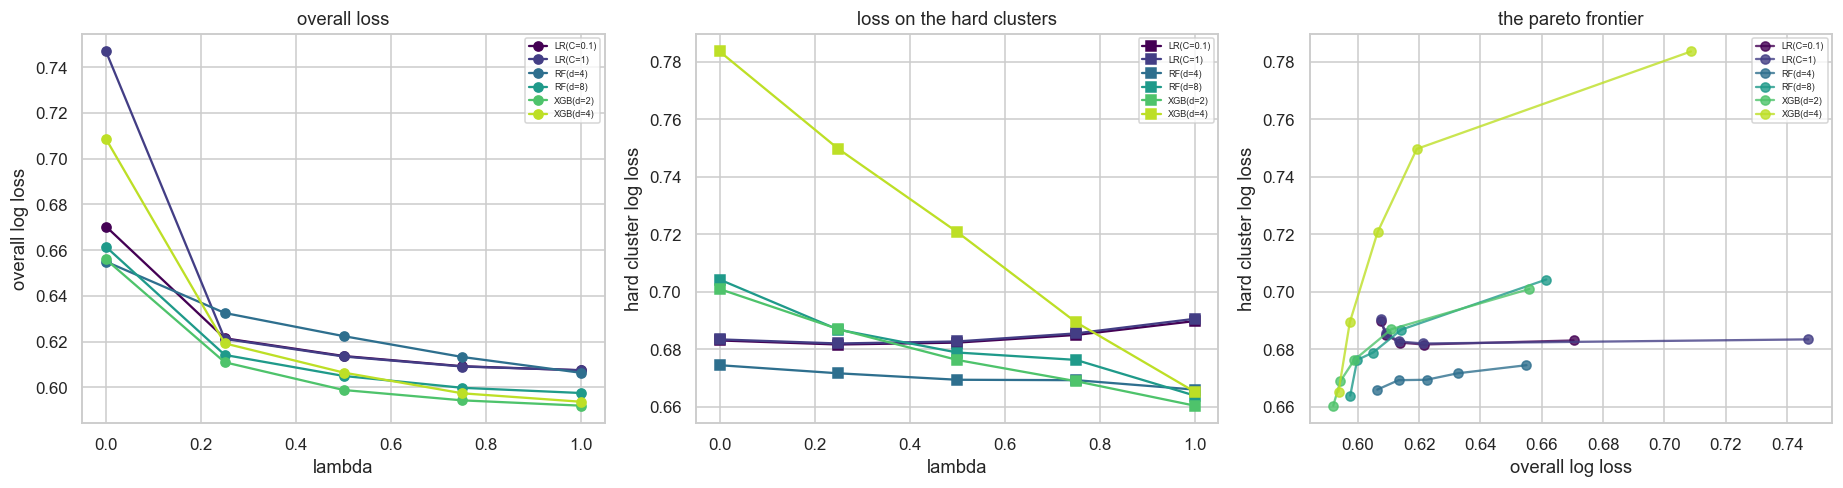

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.6))
cols = plt.cm.viridis(np.linspace(0, 0.9, len(FAMILIES)))

# overall loss, hard cluster loss, and the two against each other
for (fname, _), c in zip(FAMILIES.items(), cols):
    ov = [log_loss(y_real, P_real[f"{fname} lam={l}"]) for l in LAMBDAS]
    hd = [log_loss(y_real[HARD_MASK], P_real[f"{fname} lam={l}"][HARD_MASK], labels=[0, 1])
          for l in LAMBDAS]
    axes[0].plot(LAMBDAS, ov, "o-", color=c, label=fname)
    axes[1].plot(LAMBDAS, hd, "s-", color=c, label=fname)
    axes[2].plot(ov, hd, "o-", color=c, alpha=.8, label=fname)

axes[0].set_xlabel("lambda")
axes[0].set_ylabel("overall log loss")
axes[0].set_title("overall loss")
axes[1].set_xlabel("lambda")
axes[1].set_ylabel("hard cluster log loss")
axes[1].set_title("loss on the hard clusters")
axes[2].set_xlabel("overall log loss")
axes[2].set_ylabel("hard cluster log loss")
axes[2].set_title("the pareto frontier")
for a in axes:
    a.legend(fontsize=6)
plt.tight_layout()
plt.show()


In panel 3, the curves go up and to the right, so as lambda falls, overall loss gets worse
and hard cluster loss gets worse too. Both axes move the wrong way, there is no trade to make. The
hard clusters are hard because they are noisy rather than because they follow a different rule

Now the ensemble over the whole zoo, with the sweep above as context for what the simplex weights
end up choosing.

In [22]:
# simplex weights over the whole zoo, then how the ensemble compares to single models
w_real = fit_ensemble_weights(P_real, y_real)
singles = pd.Series({n: log_loss(y_real, P_real[n]) for n in ZOO}).sort_values()
ens_real = P_real.values @ w_real


print("real COMPAS")
print(f"  best single model in the zoo   {singles.min():.4f}  ({singles.idxmin()})")
print(f"  worst single model in the zoo  {singles.max():.4f}  ({singles.idxmax()})")
print(f"  the ensemble of all {len(ZOO)}        {log_loss(y_real, ens_real):.4f}")
print(f"  plain global logistic          {log_loss(y_real, P_real['LR(C=1) lam=1.0']):.4f}")
print()
nz = pd.Series(w_real, index=ZOO)
nz = nz[nz > 0.01].sort_values(ascending=False)
print("which models the ensemble actually uses")
for k, v in nz.items():
    print(f"  {k:22s} {v:5.3f}  {'#' * int(v * 45)}")
lam1 = sum(v for k, v in nz.items() if k.endswith("lam=1.0"))
print()
print(f"  {len(nz)} of {len(ZOO)} models get any weight at all")
print(f"  weight on lambda equals one models, which are the plain unweighted global ones, {lam1:.0%}")


real COMPAS
  best single model in the zoo   0.5920  (XGB(d=2) lam=1.0)
  worst single model in the zoo  0.7469  (LR(C=1) lam=0.0)
  the ensemble of all 30        0.5915
  plain global logistic          0.6075

which models the ensemble actually uses
  XGB(d=4) lam=1.0       0.387  #################
  XGB(d=2) lam=1.0       0.366  ################
  XGB(d=2) lam=0.75      0.127  #####
  LR(C=1) lam=1.0        0.067  ###
  LR(C=0.1) lam=1.0      0.053  ##

  5 of 30 models get any weight at all
  weight on lambda equals one models, which are the plain unweighted global ones, 87%


Does any of it beat one global model? Run on synthetic A and C as well as real COMPAS, so every
number has a scale.

In [23]:
def compare_all(y, seed=SEED):
    # zoo, weights and ensemble rebuilt from scratch for whichever labels come in
    P = build_zoo_oof(y, seed=seed)
    w = fit_ensemble_weights(P, y)
    ens = P.values @ w
    singles = pd.Series({n: log_loss(y, P[n]) for n in ZOO})
    return {
        "global logistic": log_loss(y, P["LR(C=1) lam=1.0"]),
        "global XGB": log_loss(y, P["XGB(d=2) lam=1.0"]),
        "best in zoo": singles.min(),
        "ensemble": log_loss(y, ens),
        "hard_glob": log_loss(y[HARD_MASK], P["LR(C=1) lam=1.0"][HARD_MASK], labels=[0, 1]),
        "hard_ens": log_loss(y[HARD_MASK], ens[HARD_MASK], labels=[0, 1]),
    }

res = {}
for s, y in [("synthetic A", make_synthetic("A", np.random.default_rng(11))),
             ("synthetic C", make_synthetic("C", np.random.default_rng(11))),
             ("real COMPAS", y_real)]:
    res[s] = compare_all(y)

print("cross validated log loss, lower is better")
hdr = ["global logistic", "global XGB", "best in zoo", "ensemble"]
print(f"{'dataset':>13}  " + "  ".join(f"{h:>15}" for h in hdr))
for s in res:
    print(f"{s:>13}  " + "  ".join(f"{res[s][h]:15.4f}" for h in hdr))

print()
print("and on the hard clusters, which is what the whole exercise was for")
print(f"{'dataset':>13}  {'global':>9}  {'ensemble':>9}  {'change':>9}")
for s in res:
    r = res[s]
    print(f"{s:>13}  {r['hard_glob']:9.4f}  {r['hard_ens']:9.4f}  {r['hard_ens'] - r['hard_glob']:+9.4f}")


cross validated log loss, lower is better
      dataset  global logistic       global XGB      best in zoo         ensemble
  synthetic A           0.6099           0.5894           0.5894           0.5892
  synthetic C           0.6433           0.6014           0.5897           0.5890
  real COMPAS           0.6075           0.5920           0.5920           0.5915

and on the hard clusters, which is what the whole exercise was for
      dataset     global   ensemble     change
  synthetic A     0.6935     0.6597    -0.0337
  synthetic C     0.6871     0.6282    -0.0588
  real COMPAS     0.6906     0.6623    -0.0283


Most of the apparent improvement is in A too, and that is not a discovery, upweighting a
group improves the fit on that group in any dataset.

### Each cluster gets its own weights

The sweep above pushes on all five clusters with one knob. Run it again with the knob
split five ways. Each hard cluster gets its own lambda sweep, fifteen models whose weights point at
that cluster alone, and its own simplex ensemble fitted on its own out of fold
predictions.

The null is the same protocol on synthetic A. Picking the best of fifteen models and fitting ensemble
weights inside a cluster of 60 to 150 people hands out gains on any dataset, so a per cluster gain
only means something once that cluster's own null is subtracted.

The five hardest clusters again, now each with its own mask, because from here every cluster gets
its own models rather than sharing one hard set.

In [24]:
# one boolean mask per hard cluster
MASKS = {g: (gran == g).values for g in HARD}

print("the five hardest clusters, each about to get its own models")
print(land.head(5).round(3).to_string(index=False))


the five hardest clusters, each about to get its own models
          cluster   n  global_loss
Afric|M|36-45|3-5  62        0.704
Cauca|M|36-45|3-5  63        0.702
  Cauca|M|18-25|0 144        0.689
   Afric|M|46+|6+ 152        0.688
  Afric|M|46+|3-5  82        0.687


The per cluster zoo, three families from the pooled zoo and five lambdas, one full sweep per
cluster. Every model still trains on all 6172 people, only the weights point at one cluster at a
time.

In [ ]:
PC_FAMILIES = {k: FAMILIES[k] for k in ["LR(C=1)", "XGB(d=2)", "RF(d=4)"]}

def build_percluster_oof(y, masks, seed=SEED):
    # fifteen models per cluster, weights pointing at that cluster alone
    cols = [f"{g} | {f} lam={l}" for g in masks for f in PC_FAMILIES for l in LAMBDAS]
    P = pd.DataFrame(np.zeros((len(y), len(cols))), columns=cols)
    for tr, te in StratifiedKFold(5, shuffle=True, random_state=seed).split(Xs, y):
        sc = StandardScaler().fit(Xs[tr])
        A, B = sc.transform(Xs[tr]), sc.transform(Xs[te])
        for g, m in masks.items():
            for fname, mk in PC_FAMILIES.items():
                lin = fname.startswith("LR")
                for lam in LAMBDAS:
                    w = sample_weights(m[tr], lam)
                    mod = mk().fit(A if lin else Xs[tr], y[tr], sample_weight=w)
                    P.loc[te, f"{g} | {fname} lam={lam}"] = mod.predict_proba(B if lin else Xs[te])[:, 1]
    return P

P5_real = build_percluster_oof(y_real, MASKS)
print(f"{len(HARD)} clusters times {len(PC_FAMILIES)} families times {len(LAMBDAS)} lambdas "
      f"is {P5_real.shape[1]} models")


5 clusters times 3 families times 5 lambdas is 75 models, all out of fold


One column per hard cluster. The top row is the loss on that cluster, which is the thing each
cluster's own models are supposed to improve, and the bottom row is the overall loss those same
models produce, which is the price everyone else pays.

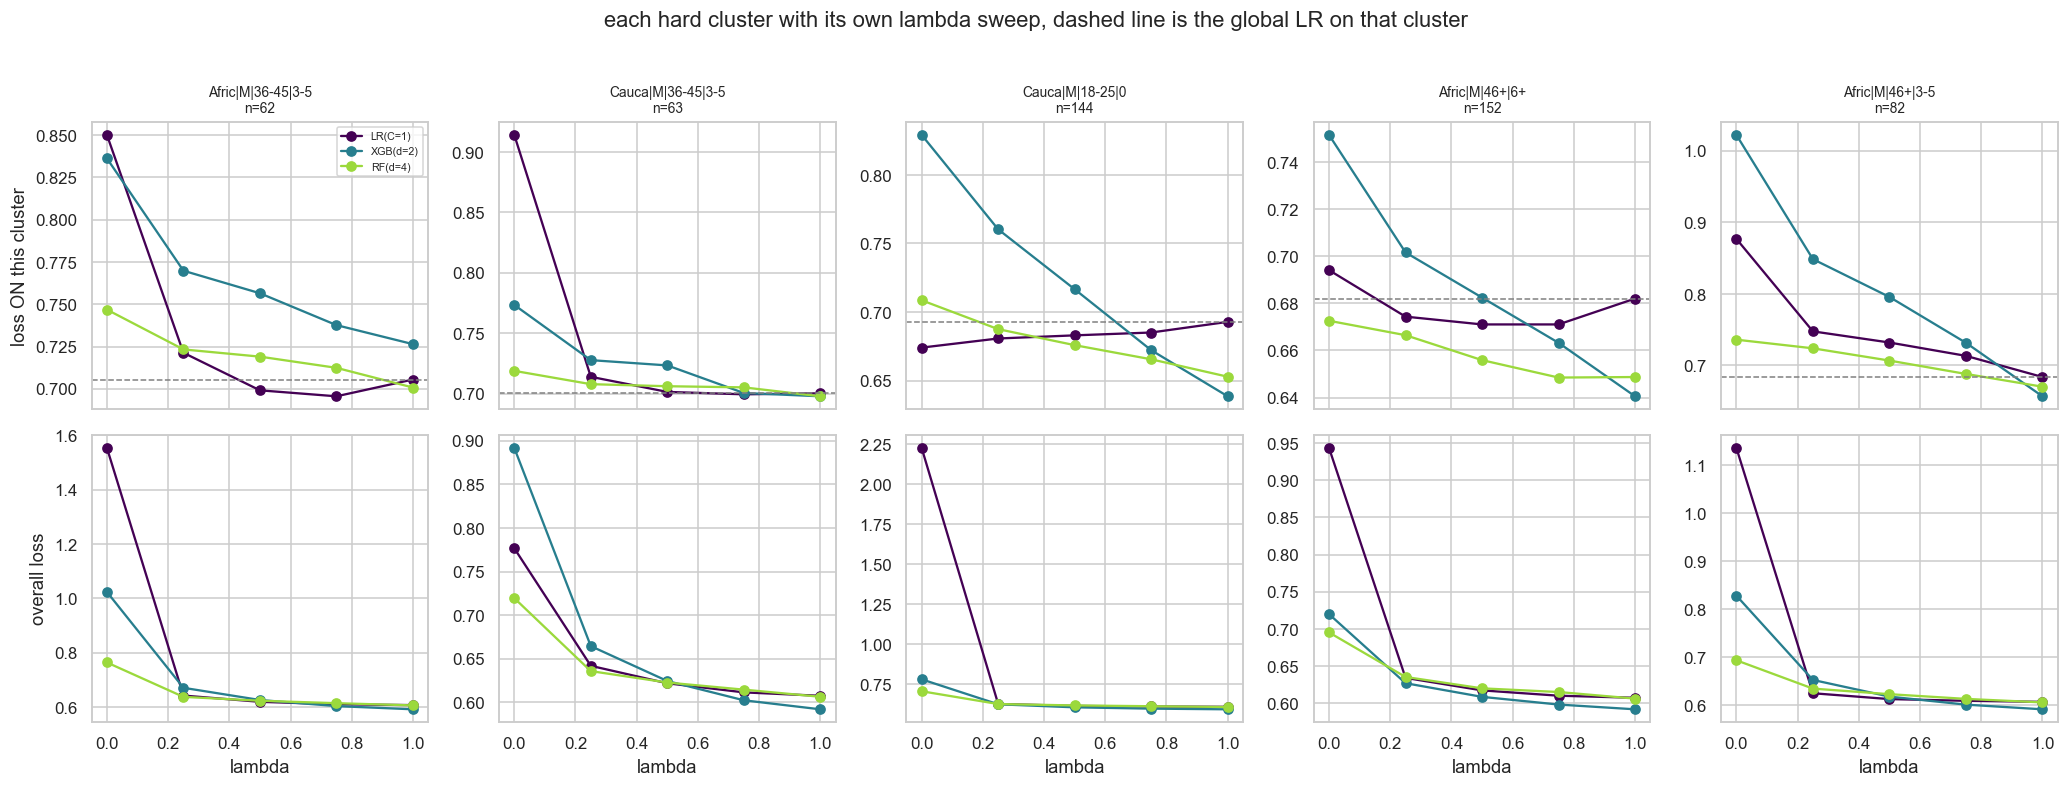

In [26]:
fig, axes = plt.subplots(2, 5, figsize=(19, 7), sharex=True)
cols = plt.cm.viridis(np.linspace(0, 0.85, len(PC_FAMILIES)))
# one column per cluster, own loss on top, overall cost underneath
for j, g in enumerate(HARD):
    m = MASKS[g]
    base = log_loss(y_real[m], P5_real[f"{g} | LR(C=1) lam=1.0"][m], labels=[0, 1])
    for (fname, _), c in zip(PC_FAMILIES.items(), cols):
        on = [log_loss(y_real[m], P5_real[f"{g} | {fname} lam={l}"][m], labels=[0, 1])
              for l in LAMBDAS]
        ov = [log_loss(y_real, P5_real[f"{g} | {fname} lam={l}"]) for l in LAMBDAS]
        axes[0, j].plot(LAMBDAS, on, "o-", color=c, label=fname)
        axes[1, j].plot(LAMBDAS, ov, "o-", color=c)
    axes[0, j].axhline(base, ls="--", c="gray", lw=1)
    axes[0, j].set_title(f"{g}\nn={m.sum()}", fontsize=9)
axes[0, 0].set_ylabel("loss ON this cluster")
axes[1, 0].set_ylabel("overall loss")
for a in axes[1]:
    a.set_xlabel("lambda")
axes[0, 0].legend(fontsize=7)
plt.suptitle("each hard cluster with its own lambda sweep, dashed line is the global LR on that cluster",
             y=1.02)
plt.tight_layout()
plt.show()


Top row: Where a curve dips below it, that cluster's reweighted
model beats the global LR on that cluster's own people. 
Bottom row: what those same models cost everyone else.

The same pareto reading as panel three of the pooled figure, drawn cluster by cluster. Each curve
is one cluster, overall loss against that cluster's own loss as lambda falls, for the linear family
on the left and the boosted family on the right. The marker is lambda equals one, the global model.
A curve heading down as it heads right would be a cluster with a real trade on offer.

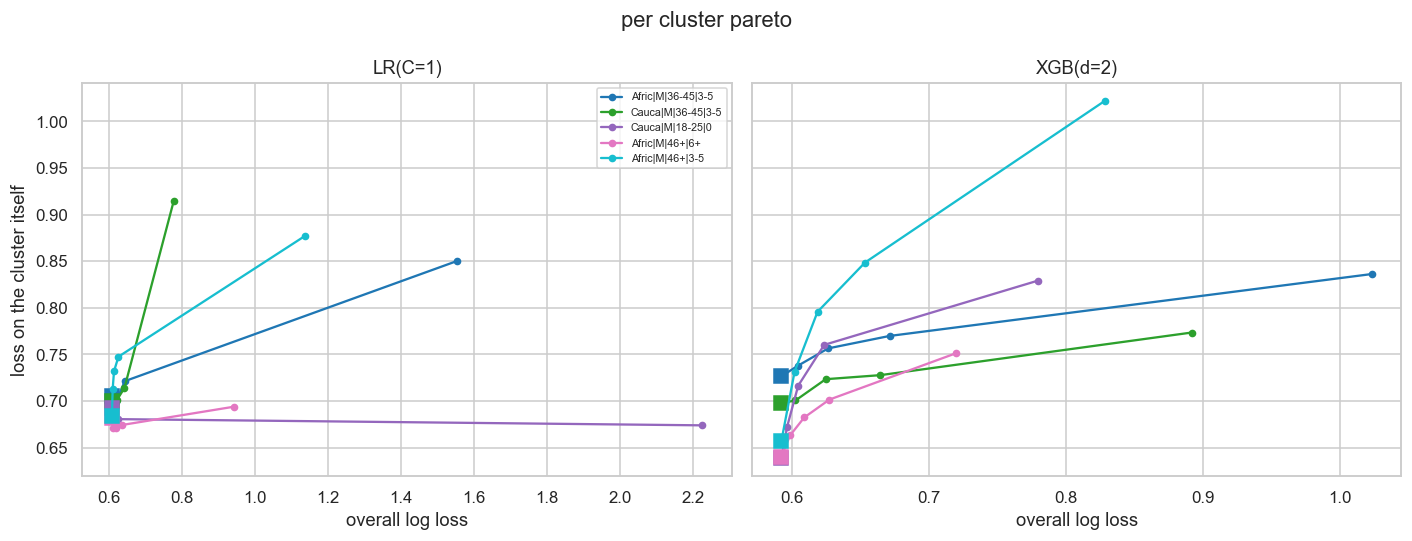

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
ccols = plt.cm.tab10(np.linspace(0, 0.9, len(HARD)))
# overall loss against own cluster loss as lambda falls, one curve per cluster
for fname, ax in zip(["LR(C=1)", "XGB(d=2)"], axes):
    for g, c in zip(HARD, ccols):
        m = MASKS[g]
        ov = [log_loss(y_real, P5_real[f"{g} | {fname} lam={l}"]) for l in LAMBDAS]
        on = [log_loss(y_real[m], P5_real[f"{g} | {fname} lam={l}"][m], labels=[0, 1])
              for l in LAMBDAS]
        ax.plot(ov, on, "o-", color=c, ms=4, label=g)
        ax.plot(ov[-1], on[-1], "s", color=c, ms=9)
    ax.set_xlabel("overall log loss")
    ax.set_title(fname)
axes[0].set_ylabel("loss on the cluster itself")
axes[0].legend(fontsize=7)
plt.suptitle("per cluster pareto")
plt.tight_layout()
plt.show()


Per cluster champions and per cluster ensembles, plus a routed predictor. The ensemble for each
cluster averages that cluster's own fifteen models with simplex weights fitted on that cluster's out
of fold predictions, and the routed predictor then gives hard cluster people their own cluster's
ensemble and everyone else the global LR.

In [29]:
def per_cluster_report(y, P, masks):
    # everyone starts with the global LR, hard cluster people get their own ensemble below
    rows, p_routed = [], P[f"{list(masks)[0]} | LR(C=1) lam=1.0"].values.copy()
    for g, m in masks.items():
        # this cluster's fifteen columns, its champion, and its own simplex ensemble
        gcols = [c for c in P.columns if c.startswith(g + " |")]
        gl_lr = log_loss(y[m], P[f"{g} | LR(C=1) lam=1.0"][m], labels=[0, 1])
        gl_xgb = log_loss(y[m], P[f"{g} | XGB(d=2) lam=1.0"][m], labels=[0, 1])
        losses = {c: log_loss(y[m], P[c][m], labels=[0, 1]) for c in gcols}
        best = min(losses, key=losses.get)
        w = fit_ensemble_weights(P[gcols][m], y[m])
        p_ens = np.clip(P[gcols].values[m] @ w, 1e-6, 1 - 1e-6)
        p_routed[m] = p_ens
        rows.append({"cluster": g, "n": int(m.sum()),
                     "global_LR": gl_lr, "global_XGB": gl_xgb,
                     "best_single": losses[best], "champion": best.split("| ")[1],
                     "own_ensemble": log_loss(y[m], p_ens, labels=[0, 1])})
    rep = pd.DataFrame(rows)
    # routed losses, overall and on the hard clusters pooled
    hm = np.zeros(len(y), bool)
    for m in masks.values():
        hm |= m
    routed = {"overall_global": log_loss(y, P[f"{list(masks)[0]} | LR(C=1) lam=1.0"]),
              "overall_routed": log_loss(y, np.clip(p_routed, 1e-6, 1 - 1e-6)),
              "hard_global": log_loss(y[hm], P[f"{list(masks)[0]} | LR(C=1) lam=1.0"][hm], labels=[0, 1]),
              "hard_routed": log_loss(y[hm], np.clip(p_routed[hm], 1e-6, 1 - 1e-6), labels=[0, 1])}
    return rep, routed

rep_real, routed_real = per_cluster_report(y_real, P5_real, MASKS)
print("real COMPAS. every loss is out of fold and scored on that cluster alone")
print(rep_real.round(4).to_string(index=False))
print()
n_lam1 = sum(rep_real["champion"].str.endswith("lam=1.0"))
print(f"{n_lam1} of 5 are the unweighted global model")

print("the routed predictor, own ensemble inside a hard cluster and global LR outside")
print(f"  overall   global {routed_real['overall_global']:.4f}   routed {routed_real['overall_routed']:.4f}")
print(f"  hard 5    global {routed_real['hard_global']:.4f}   routed {routed_real['hard_routed']:.4f}")


real COMPAS. every loss is out of fold and scored on that cluster alone
          cluster   n  global_LR  global_XGB  best_single         champion  own_ensemble
Afric|M|36-45|3-5  62     0.7055      0.7265       0.6956 LR(C=1) lam=0.75        0.6926
Cauca|M|36-45|3-5  63     0.7004      0.6980       0.6980 XGB(d=2) lam=1.0        0.6732
  Cauca|M|18-25|0 144     0.6928      0.6385       0.6385 XGB(d=2) lam=1.0        0.6372
   Afric|M|46+|6+ 152     0.6820      0.6405       0.6405 XGB(d=2) lam=1.0        0.6406
  Afric|M|46+|3-5  82     0.6838      0.6568       0.6568 XGB(d=2) lam=1.0        0.6568

4 of 5 are the unweighted global model
the routed predictor, own ensemble inside a hard cluster and global LR outside
  overall   global 0.6075   routed 0.6044
  hard 5    global 0.6906   routed 0.6528


In [30]:
# the whole per cluster protocol repeated on three draws of synthetic A
N_REPS_A = 3
reps = []
for r in range(N_REPS_A):
    yA = make_synthetic("A", np.random.default_rng(900 + r))
    PA = build_percluster_oof(yA, MASKS)
    repA, routedA = per_cluster_report(yA, PA, MASKS)
    repA["rep"] = r
    repA["routed_hard_gain"] = routedA["hard_global"] - routedA["hard_routed"]
    reps.append(repA)
repsA = pd.concat(reps)

# gain of the own ensemble over the global LR, real against the null, per cluster
gain_real = rep_real["global_LR"] - rep_real["own_ensemble"]
gain_A = (repsA["global_LR"] - repsA["own_ensemble"]).groupby(repsA["cluster"]).mean()
tbl = pd.DataFrame({"gain_real": gain_real.values,
                    "gain_synthA": gain_A.reindex(rep_real["cluster"]).values},
                   index=rep_real["cluster"])
tbl["survives"] = tbl["gain_real"] - tbl["gain_synthA"]

print("per cluster gain of the own ensemble over the global LR, real against the null")
print(tbl.round(4).to_string())
print()
print(f"mean gain on real COMPAS      {gain_real.mean():+.4f}")
print(f"mean gain on synthetic A      {(repsA['global_LR'] - repsA['own_ensemble']).mean():+.4f}")
print(f"routed hard gain on real      {routed_real['hard_global'] - routed_real['hard_routed']:+.4f}")
print(f"routed hard gain on A, mean   {repsA.groupby('rep')['routed_hard_gain'].first().mean():+.4f}")


per cluster gain of the own ensemble over the global LR, real against the null
                   gain_real  gain_synthA  survives
cluster                                            
Afric|M|36-45|3-5     0.0129       0.0070    0.0059
Cauca|M|36-45|3-5     0.0273       0.0236    0.0036
Cauca|M|18-25|0       0.0556       0.0322    0.0234
Afric|M|46+|6+        0.0414       0.0323    0.0092
Afric|M|46+|3-5       0.0270       0.0246    0.0024

mean gain on real COMPAS      +0.0328
mean gain on synthetic A      +0.0239
routed hard gain on real      +0.0378
routed hard gain on A, mean   +0.0268
